# Datapunt 2 - Segmentatie met CBS Open Data (K-Means)

Dit notebook laadt **Kerncijfers Wijken en Buurten** van het CBS, kiest automatisch bruikbare variabelen zoals inkomen en bevolkingsdichtheid, past **K-Means clustering** toe en maakt twee visualisaties plus clusterprofielen.


In [51]:
import warnings
warnings.filterwarnings("ignore")

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [52]:
# ==========================================
# 1. INSTELLINGEN & FUNCTIES
# ==========================================
TABLE_ID = "85984NED"
BASE_URL = f"https://opendata.cbs.nl/ODataApi/OData/{TABLE_ID}"
RANDOM_STATE = 42
MAX_CBS_ROWS_PER_QUERY = 9_500
WIJK_CODE_LENGTH = 8


def get_odata(url, timeout=60):
    """Downloadt alle pagina's van een CBS OData endpoint en combineert die tot één DataFrame."""
    rows = []
    next_url = url
    while next_url:
        response = requests.get(next_url, timeout=timeout)
        response.raise_for_status()
        payload = response.json()
        if "value" in payload:
            chunk = payload["value"]
            next_url = payload.get("@odata.nextLink")
        elif "d" in payload:
            d = payload["d"]
            chunk = d.get("results", [])
            next_url = d.get("__next")
        else:
            raise RuntimeError("Onbekend OData-responseformaat ontvangen van CBS.")
        rows.extend(chunk)
    return pd.DataFrame(rows)


def prepare_text_columns(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str).str.strip()
    return df


def find_key(metadata, include_terms=None, exclude_terms=None, key_prefixes=None, type_contains=None, required=False, label="veld"):
    include_terms = include_terms or []
    exclude_terms = exclude_terms or []
    key_prefixes = key_prefixes or []
    type_contains = type_contains or []

    meta = metadata.copy()
    title = meta.get("Title", pd.Series("", index=meta.index)).fillna("").astype(str)
    description = meta.get("Description", pd.Series("", index=meta.index)).fillna("").astype(str)
    key_series = meta.get("Key", pd.Series("", index=meta.index)).fillna("").astype(str)
    type_series = meta.get("Type", pd.Series("", index=meta.index)).fillna("").astype(str)

    search_text = (title + " " + description).str.lower()
    mask = pd.Series(True, index=meta.index)

    for term in include_terms:
        mask &= search_text.str.contains(term.lower(), regex=False)
    for term in exclude_terms:
        mask &= ~search_text.str.contains(term.lower(), regex=False)

    if key_prefixes:
        prefix_mask = pd.Series(False, index=meta.index)
        for prefix in key_prefixes:
            prefix_mask |= key_series.str.startswith(prefix)
        mask &= prefix_mask

    if type_contains:
        type_mask = pd.Series(False, index=meta.index)
        for term in type_contains:
            type_mask |= type_series.str.contains(term, case=False, regex=False)
        mask &= type_mask

    matches = meta[mask].copy()
    if not matches.empty:
        matches["title_len"] = matches["Title"].fillna("").astype(str).str.len()
        return matches.sort_values(["title_len", "Key"]).iloc[0]["Key"]

    if required:
        raise KeyError(f"Kon geen {label} vinden. include_terms={include_terms}, exclude_terms={exclude_terms}, key_prefixes={key_prefixes}, type_contains={type_contains}")
    return None


def choose_feature_keys(metadata):
    feature_specs = {
        "inkomen": [(["gestandaardiseerd inkomen"], [], []), (["gemiddeld inkomen"], [], []), (["besteedbaar inkomen"], [], [])],
        "dichtheid": [(["bevolkingsdichtheid"], [], []), (["omgevingsadressendichtheid"], [], [])],
        "inwoners": [(["aantal inwoners"], [], []), (["inwoners"], ["percentage"], [])],
        "vermogen": [(["mediaan vermogen"], [], []), (["vermogen particuliere huishoudens"], [], [])],
        "bijstand": [(["bijstand"], ["jeugd"], []), (["uitkering", "bijstand"], [], [])],
        "woningen": [(["woningvoorraad"], [], []), (["woningen"], ["gemiddeld"], [])],
        "ouderen": [(["65 jaar of ouder"], [], []), (["65 jaar"], ["gemiddelde leeftijd"], [])],
    }
    chosen = {}
    for logical_name, pattern_sets in feature_specs.items():
        for inc, exc, pref in pattern_sets:
            key = find_key(metadata, include_terms=inc, exclude_terms=exc, key_prefixes=pref, required=False, label=logical_name)
            if key and key not in chosen.values():
                chosen[logical_name] = key
                break
    return chosen


def build_typed_dataset_url(select_keys, filters=None):
    params = ["$format=json", f"$select={','.join(select_keys)}"]
    if filters:
        params.append(f"$filter={filters}")
    return BASE_URL + "/TypedDataSet?" + "&".join(params)


def is_cbs_query_limit_error(exc):
    response = getattr(exc, "response", None)
    if response is None:
        return False
    return response.status_code == 500 and "returns less than 10000 records" in response.text


def parse_period_sort_value(value):
    text = str(value or "").strip()
    if not text:
        return (-1, "")
    digits = "".join(ch for ch in text if ch.isdigit())
    year = int(digits[:4]) if len(digits) >= 4 else -1
    remainder = digits[4:] if len(digits) > 4 else ""
    suffix = "".join(ch for ch in text if not ch.isdigit())
    return (year, remainder, suffix, text)


def get_latest_dimension_value(dimension_key):
    dimension_df = get_odata(f"{BASE_URL}/{dimension_key}?$format=json")
    if dimension_df.empty:
        raise RuntimeError(f"Geen waarden gevonden voor CBS-dimensie {dimension_key!r}.")

    candidate_columns = [col for col in ["Key", f"{dimension_key}Key", f"{dimension_key}_Key", dimension_key] if col in dimension_df.columns]
    if not candidate_columns:
        candidate_columns = [dimension_df.columns[0]]

    key_column = candidate_columns[0]
    dimension_df = dimension_df.dropna(subset=[key_column]).copy()
    if dimension_df.empty:
        raise RuntimeError(f"CBS-dimensie {dimension_key!r} bevat geen bruikbare sleutels.")

    dimension_df["__sort_key"] = dimension_df[key_column].map(parse_period_sort_value)
    latest_row = dimension_df.sort_values("__sort_key").iloc[-1]
    return str(latest_row[key_column]).strip()


def combine_filters(*filters):
    valid_filters = [f for f in filters if f]
    return " and ".join(valid_filters)


def fetch_region_dataset(select_keys, region_code_key, prefixes, base_filter=None, max_rows=MAX_CBS_ROWS_PER_QUERY, branch_chars="0123456789", exact_code_length=WIJK_CODE_LENGTH):
    """Laadt CBS-regio's in batches en splitst prefixes automatisch verder bij de CBS 10.000-recordlimiet."""
    batches = []
    pending_queries = [
        {
            "label": prefix,
            "filter": combine_filters(base_filter, f"startswith({region_code_key},'{prefix}')"),
            "prefix": prefix,
            "mode": "prefix",
        }
        for prefix in prefixes
    ]

    while pending_queries:
        query = pending_queries.pop(0)
        batch_url = build_typed_dataset_url(select_keys, query["filter"])

        try:
            batch_df = get_odata(batch_url)
        except requests.HTTPError as exc:
            if is_cbs_query_limit_error(exc):
                prefix = query["prefix"]
                if query["mode"] == "prefix" and len(prefix) < exact_code_length:
                    refined_queries = [
                        {
                            "label": f"{prefix}{char}",
                            "filter": combine_filters(base_filter, f"startswith({region_code_key},'{prefix}{char}')"),
                            "prefix": f"{prefix}{char}",
                            "mode": "prefix",
                        }
                        for char in branch_chars
                    ]
                    pending_queries = refined_queries + pending_queries
                    print(f"  - prefix {prefix}: te groot, opgesplitst in {len(refined_queries)} subprefixen")
                    continue

                if query["mode"] == "prefix" and len(prefix) == exact_code_length:
                    exact_query = {
                        "label": f"{prefix} (exact)",
                        "filter": combine_filters(base_filter, f"{region_code_key} eq '{prefix}'"),
                        "prefix": prefix,
                        "mode": "exact",
                    }
                    pending_queries = [exact_query] + pending_queries
                    print(f"  - prefix {prefix}: prefixlimiet bereikt, opnieuw proberen als exacte regiocode")
                    continue

                raise RuntimeError(
                    f"CBS-query voor prefix {prefix!r} blijft boven de limiet; kan niet verder verfijnen."
                ) from exc
            raise

        if batch_df.empty:
            continue
        if len(batch_df) >= max_rows:
            print(f"  - {query['label']}: waarschuwing, {len(batch_df):,} records opgehaald")
        else:
            print(f"  - {query['label']}: {len(batch_df):,} records")
        batches.append(batch_df)

    if not batches:
        raise RuntimeError("Er zijn geen CBS-regio's opgehaald met de gekozen filters.")

    combined = pd.concat(batches, ignore_index=True)
    combined = combined.drop_duplicates(subset=[region_code_key]).reset_index(drop=True)
    return combined


def elbow_k(inertias, k_values):
    """Gecorrigeerde elbow-heuristiek met normalisatie"""
    k_min, k_max = min(k_values), max(k_values)
    i_min, i_max = min(inertias), max(inertias)

    k_norm = [(k - k_min) / (k_max - k_min) for k in k_values]
    i_norm = [(i - i_min) / (i_max - i_min) for i in inertias]

    x1, y1 = k_norm[0], i_norm[0]
    x2, y2 = k_norm[-1], i_norm[-1]
    distances = []

    for x0, y0 in zip(k_norm, i_norm):
        numerator = abs((y2 - y1) * x0 - (x2 - x1) * y0 + x2 * y1 - y2 * x1)
        denominator = math.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
        distances.append(numerator / denominator)

    return k_values[int(np.argmax(distances))]


def get_title(metadata, key):
    rows = metadata.loc[metadata["Key"] == key, "Title"]
    return rows.iloc[0] if not rows.empty else key




In [53]:
# ==========================================
# 2. METADATA & FEATURE SELECTIE (ROBUUST)
# ==========================================
print("Ophalen van metadata...")
metadata = get_odata(BASE_URL + "/DataProperties?$format=json")
metadata = prepare_text_columns(metadata, ["Title", "Description", "Key", "Type"])
metadata = metadata[metadata["Key"].fillna("").astype(str).str.strip() != ""].copy()

# Splits metadata: Alles wat GEEN 'Topic' is, zien we als structuur/dimensie
dimensions_metadata = metadata[~metadata["Type"].str.contains("Topic", case=False, na=False)].copy()
topics_metadata = metadata[metadata["Type"].str.contains("Topic", case=False, na=False)].copy()

print(f"Metadata gesplitst: {len(dimensions_metadata)} dimensies en {len(topics_metadata)} onderwerpen.")

# --- REGIO SELECTIE ---
# We zoeken nu eerst naar 'GeoDetail' (jouw specifieke type) of termen als 'regio'/'wijk'
region_code_key = (
    find_key(dimensions_metadata, type_contains="GeoDetail", required=False)
    or find_key(dimensions_metadata, include_terms=["codering", "regio", "wijk", "buurt"], required=False)
    or (dimensions_metadata.iloc[0]["Key"] if not dimensions_metadata.empty else None)
)

if not region_code_key:
    # Als er echt niets is, tonen we wat we wel hebben voor diagnose
    print("Beschikbare velden in dimensions_metadata:")
    print(dimensions_metadata[["Key", "Title", "Type"]])
    raise KeyError("Kon geen regiocode-dimensie vinden.")

print(f"Geselecteerde regio_code_key: {region_code_key}")

# De naam-key is bij wijken/buurten vaak hetzelfde als de code-key
region_name_key = (
    find_key(dimensions_metadata, include_terms=["naam"], exclude_terms=["straat"], required=False)
    or region_code_key
)

# --- PERIODE SELECTIE ---
# We zoeken breed. Als 'Perioden' niet bestaat, gebruiken we None.
period_key = find_key(dimensions_metadata, include_terms=["Perioden", "jaar", "period"], required=False)

latest_period_value = None
if period_key:
    print(f"Gevonden period_key: {period_key}")
    try:
        latest_period_value = get_latest_dimension_value(period_key)
        print(f"Geselecteerde CBS-periode: {latest_period_value}")
    except Exception as e:
        print(f"Kon periode-waarden niet ophalen: {e}")
else:
    print("Info: Geen periode-dimensie gevonden. De dataset bevat mogelijk maar één tijdstip.")

# --- FEATURE SELECTIE ---
# Gebruik de topics_metadata voor de inhoudelijke variabelen (inkomen, etc.)
chosen_features = choose_feature_keys(topics_metadata)

print("--- Selectie voltooid ---")
print(f"Regio: {region_code_key}, Periode: {latest_period_value}")
print(f"Features: {chosen_features}")

Ophalen van metadata...
Metadata gesplitst: 1 dimensies en 121 onderwerpen.
Geselecteerde regio_code_key: WijkenEnBuurten
Info: Geen periode-dimensie gevonden. De dataset bevat mogelijk maar één tijdstip.
--- Selectie voltooid ---
Regio: WijkenEnBuurten, Periode: None
Features: {'inkomen': 'GemGestandaardiseerdInkomen_83', 'dichtheid': 'Bevolkingsdichtheid_34', 'inwoners': 'Gehuwd_14', 'vermogen': 'MediaanVermogenVanParticuliereHuish_86', 'bijstand': 'PersonenPerSoortUitkeringBijstand_87', 'woningen': 'Woningvoorraad_35', 'ouderen': 'k_65JaarOfOuder_12'}


In [54]:
# ==========================================
# 3. DATA DOWNLOAD (in batches onder de CBS limiet)
# ==========================================
selected_keys = [region_code_key, region_name_key]
if region_type_key:
    selected_keys.append(region_type_key)
if period_key:
    selected_keys.append(period_key)
selected_keys += list(chosen_features.values())
selected_keys = list(dict.fromkeys(selected_keys))

base_filter = f"{period_key} eq '{latest_period_value}'" if latest_period_value else None
region_prefixes = [f"WK{i:02d}" for i in range(100)]
print("\nBezig met downloaden van de CBS dataset in batches per wijk-prefix...")
cbs_df = fetch_region_dataset(
    selected_keys,
    region_code_key,
    region_prefixes,
    base_filter=base_filter,
    exact_code_length=WIJK_CODE_LENGTH,
)
print("Ruwe CBS dataset-vorm:", cbs_df.shape)





Bezig met downloaden van de CBS dataset in batches per wijk-prefix...
  - WK00: 204 records
  - WK01: 279 records
  - WK02: 240 records
  - WK03: 415 records
  - WK04: 197 records
  - WK05: 229 records
  - WK06: 156 records
  - WK07: 238 records
  - WK08: 202 records
  - WK09: 148 records
  - WK15: 53 records
  - WK16: 180 records
  - WK17: 254 records
  - WK18: 61 records
  - WK19: 537 records
Ruwe CBS dataset-vorm: (3393, 9)


In [55]:
# ==========================================
# 4. DATA SCHOONMAKEN & IMPUTEREN
# ==========================================
text_cols = [region_code_key, region_name_key]
if region_type_key:
    text_cols.append(region_type_key)
cbs_df = prepare_text_columns(cbs_df, text_cols)

missing_markers = {".": np.nan, "..": np.nan, "x": np.nan, "-": np.nan, " ": np.nan, "": np.nan}
for col in cbs_df.columns:
    if col not in text_cols:
        cbs_df[col] = cbs_df[col].replace(missing_markers)
        cbs_df[col] = pd.to_numeric(cbs_df[col], errors="coerce")

feature_cols_all = list(chosen_features.values())
required_feature_keys = [chosen_features["inkomen"], chosen_features["dichtheid"]]
missing_ratio = cbs_df[feature_cols_all].isna().mean().sort_values()

feature_cols = []
for col in feature_cols_all:
    if col in required_feature_keys or missing_ratio[col] <= 0.35:
        feature_cols.append(col)

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(cbs_df[feature_cols]),
    columns=feature_cols,
    index=cbs_df.index,
)

model_df = cbs_df[[region_code_key, region_name_key] + ([region_type_key] if region_type_key else [])].copy()
for col in feature_cols:
    model_df[col] = X_imputed[col].values

print("\nOpgeschoonde CBS dataset-vorm:", model_df.shape)


Opgeschoonde CBS dataset-vorm: (3393, 10)


In [56]:
# ==========================================
# 5. K-MEANS CLUSTERING & ELBOW
# ==========================================
X = model_df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = list(range(2, 11))
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

best_k = elbow_k(inertias, k_values)
print("\nAutomatisch gekozen aantal clusters (elbow):", best_k)


Automatisch gekozen aantal clusters (elbow): 6


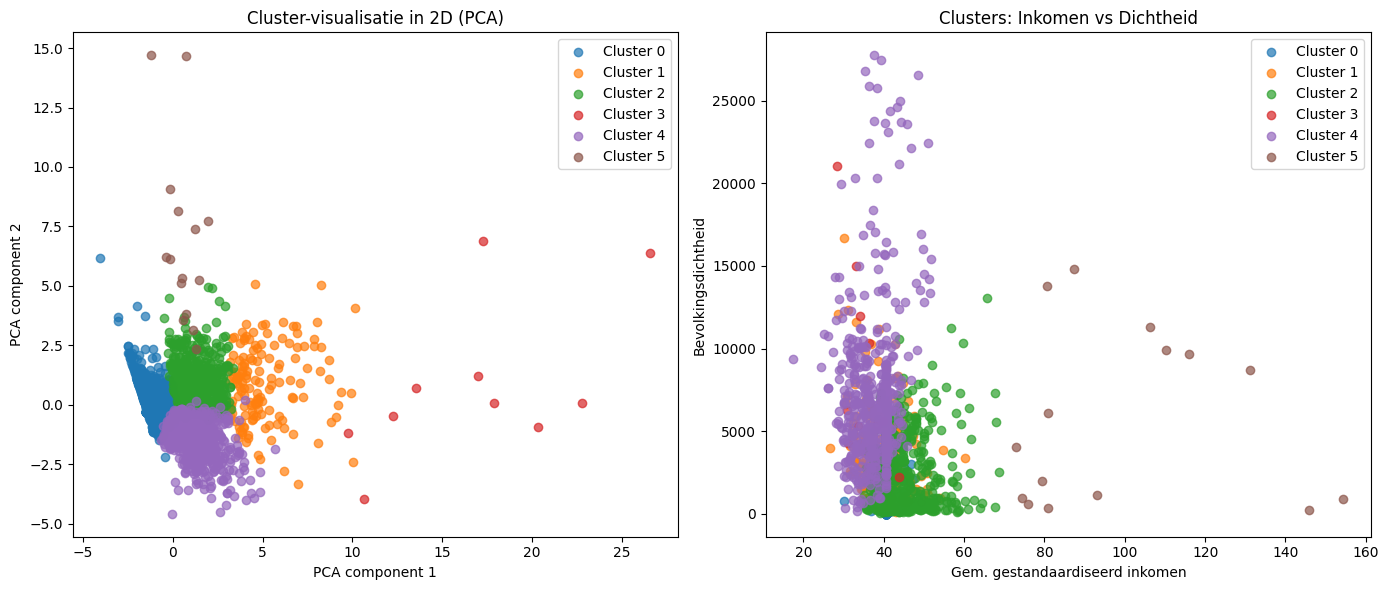

In [57]:
# ==========================================
# 6. VISUALISATIES
# ==========================================
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
model_df["cluster"] = kmeans.fit_predict(X_scaled)

# PCA Plot
pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_scaled)
plot_df = model_df.copy()
plot_df["pca_1"] = components[:, 0]
plot_df["pca_2"] = components[:, 1]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for cluster_id in sorted(plot_df["cluster"].unique()):
    subset = plot_df[plot_df["cluster"] == cluster_id]
    plt.scatter(subset["pca_1"], subset["pca_2"], label=f"Cluster {cluster_id}", alpha=0.7)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Cluster-visualisatie in 2D (PCA)")
plt.legend()

# Income vs Density Plot
income_col = chosen_features["inkomen"]
density_col = chosen_features["dichtheid"]

plt.subplot(1, 2, 2)
for cluster_id in sorted(model_df["cluster"].unique()):
    subset = model_df[model_df["cluster"] == cluster_id]
    plt.scatter(subset[income_col], subset[density_col], label=f"Cluster {cluster_id}", alpha=0.7)
plt.xlabel(get_title(metadata, income_col))
plt.ylabel(get_title(metadata, density_col))
plt.title("Clusters: Inkomen vs Dichtheid")
plt.legend()

plt.tight_layout()
plt.show()

In [58]:
# ==========================================
# 7. CONCLUSIES
# ==========================================
profile_df = model_df.groupby("cluster")[feature_cols].mean().round(2)

def cluster_label(cluster_id, row, overall_means, income_col, density_col):
    income_value = row[income_col]
    density_value = row[density_col]
    if income_value >= overall_means[income_col] and density_value >= overall_means[density_col]:
        short_desc = "hoger inkomen en hogere dichtheid"
    elif income_value >= overall_means[income_col] and density_value < overall_means[density_col]:
        short_desc = "hoger inkomen en lagere dichtheid"
    elif income_value < overall_means[income_col] and density_value >= overall_means[density_col]:
        short_desc = "lager inkomen en hogere dichtheid"
    else:
        short_desc = "lager inkomen en lagere dichtheid"
    return f"Cluster {cluster_id}: {short_desc}."

overall_means = model_df[feature_cols].mean()

print("\nClusterprofielen:")
print("-" * 20)
for cluster_id, row in profile_df.iterrows():
    print(cluster_label(cluster_id, row, overall_means, income_col, density_col))
    example_regions = model_df[model_df["cluster"] == cluster_id][region_name_key].head(5).tolist()
    print("Voorbeelden:", ", ".join(example_regions))
    print()

print("Technische conclusie")
print("--------------------")
print(f"Er zijn {len(model_df):,} regio's gebruikt voor clustering.")
print(f"De elbow-methode koos k = {best_k} clusters.")
print(f"Het model gebruikt {len(feature_cols)} kenmerken.")
print("Ontbrekende waarden zijn met de mediaan geïmputeerd.")


Clusterprofielen:
--------------------
Cluster 0: lager inkomen en lagere dichtheid.


AttributeError: 'DataFrame' object has no attribute 'tolist'